# Lassa seroreactivity — paper figure notebook

This notebook contains only the analyses and plots needed for the current paper story.

**Core narrative**
1. Population level: identify the most prevalent seroreactive viral genuses across viral families.
2. Individual level: show how those species-level responses are distributed across Lassa fever survivors, household contacts, and US healthy controls.
3. Outcome: test whether selected viral species distinguish survivors from household contacts.
4. Sequence mechanism: use exact 8-aa sequence linkage to visualize representative cross-species peptide clusters containing *Mammarenavirus lassaense* and *Orthonairovirus haemorrhagiae*.
5. Merge ELISA data with PhIP-Seq seroreactivity data.

The standardized master peptide library is the sole peptide annotation/reference file used downstream. Original annotations are retained in that file, while standardized ICTV 2025 taxonomy and protein annotations are used for analysis and plotting.

In [65]:

# 0. IMPORTS AND CONFIGURATION


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from collections import defaultdict
from itertools import combinations
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

sns.set_context('notebook')
sns.set_style('white')

# Input files -

Z_SL_FILE = 'z_score_df_SL_over_US_090226.csv'
Z_HBDB_FILE = 'z_hbdb_loo_results_090226.csv'
RPK_SL_FILE = './preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv'
RPK_HBDB_FILE = './preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv'
LASV_ELISA_FILE = '../LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv'
REFERENCE_PEPTIDE_FILE = 'lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv'


# Analysis thresholds -

Z_THRESH = 3
SENS_MIN = 0.05
SPEC_MIN = 0.99

# Remove taxa/accessions excluded from the original downstream analysis
TAXA_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']
ACCESSIONS_TO_REMOVE = ['WAK75154.1', 'ANT96597.1'] #accessions mapping to ampicillin resistance proteins found in vaccine constructs

# Heatmap selection
TOP_N_PER_FAMILY = 2

# Network targets
TARGET_LASSA = 'Mammarenavirus lassaense'
TARGET_HAEM = 'Orthonairovirus haemorrhagiae'

FIG_DIR = './paper_figures'

## 1. Load standardized peptide reference and z-score matrices

Only the standardized master peptide library is used to supply peptide sequence, accession, ICTV species/genus/family, and standardized protein information. The z-score files provide the participant-level seroreactivity measurements.

In [2]:

# 1. LOAD INPUTS -


import os
os.makedirs(FIG_DIR, exist_ok=True)

# Participant z-scores
df_sl_z = pd.read_csv(Z_SL_FILE).set_index('peptide')
df_hbdb_z = pd.read_csv(Z_HBDB_FILE).set_index('peptide')

# participant rpk values
df_sl_rpk = pd.read_csv(RPK_SL_FILE).set_index('peptide')
df_hbdb_rpk = pd.read_csv(RPK_HBDB_FILE).set_index('peptide')

### 2. Define the filtered high-specificity peptide set

A peptide is considered reactive when its participant-level z-score is >3. Peptides retained for the downstream viral analysis have ≥5% sensitivity in the SL cohort and ≥99% specificity in HBDB, followed by the same exclusion of non-target taxa/artificial-vector accessions used previously.

In [3]:

# 2. PEPTIDE-LEVEL FILTERING -


pass_sl = df_sl_z > Z_THRESH
pass_hbdb = df_hbdb_z > Z_THRESH

peptide_stats = pd.DataFrame({
    'sensitivity': pass_sl.mean(axis=1),
    'specificity': 1 - pass_hbdb.mean(axis=1)
})


hits = peptide_stats[
    (peptide_stats['sensitivity'] >= SENS_MIN) &
    (peptide_stats['specificity'] >= SPEC_MIN)
].copy()

hits = pd.DataFrame(hits).reset_index('peptide')

print(hits.peptide.nunique(), 'before exclusion of taxa and accessions')


1292 before exclusion of taxa and accessions


In [4]:
peps_metadata = pd.read_csv(REFERENCE_PEPTIDE_FILE)
peps_metadata.rename(columns={'seq_id':'peptide'}, inplace=True)

In [5]:
hits = hits.merge(peps_metadata, on='peptide', how='left')

In [6]:
hits.head(1)
hits.columns.to_list()

['peptide',
 'sensitivity',
 'specificity',
 'sequence',
 'accession',
 'protein_name',
 'gene',
 'segment',
 'order',
 'family',
 'subfamily',
 'genus',
 'species',
 'isolate',
 'taxonomy_lineage',
 'collection_date',
 'geo_loc_name',
 'host',
 'protein_std',
 'fragment',
 'collection_date_standardized']

In [7]:
hits.to_csv('pep_hits_090726.csv')


### from those peptide hits I want to add the ICTV recognized and standardized species name, and standardize the protein it belongs to e.g. nucleoprotein, NP, capsid --> nucleoprotein

In [8]:

# Original analysis exclusions
hits = hits[
    ~hits['family'].isin(TAXA_TO_REMOVE)
].copy()

hits = hits[
    ~hits['accession'].isin(ACCESSIONS_TO_REMOVE)
].copy()


print(f'Filtered peptide hits: {hits.peptide.nunique()}')
print(f'Unique standardized species: {hits.species.nunique()}')
print(f'Unique standardized genera: {hits.genus.nunique()}')
print(f'Unique standardized families: {hits.family.nunique()}')

Filtered peptide hits: 1274
Unique standardized species: 366
Unique standardized genera: 42
Unique standardized families: 9


In [9]:
hits['accession'].nunique()

797

In [10]:
hits.to_csv('pep_hits_wo_taxa_to_remove_090726.csv')

In [16]:

# 3. LONG-FORM PARTICIPANT DATA -

df_z = pd.concat([df_sl_z, df_hbdb_z], axis=1)
df_rpk = pd.concat([df_sl_rpk, df_hbdb_rpk], axis=1)

z_long = (
    df_z.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide',
        var_name='individual',
        value_name='z_score'
    )
)

rpk_long = (
    df_rpk.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide', 
        var_name='individual', 
        value_name='rpk'
    )
)

long = z_long.merge(
    rpk_long, 
    on=['peptide', 'individual'], 
    how='left'
)


long = long.merge(
    hits[
        [
            'peptide', 'sequence', 'species', 'genus', 'family',
            'protein_std', 'accession'
        ]
    ].drop_duplicates('peptide'),
    on='peptide',
    how='left'
)

long['cohort'] = np.where(
    z_long['individual'].str.startswith('HBDB-'),
    'HBDB',
    'SL'
)

long['category'] = np.select(
    [
        long['individual'].str.startswith('S-'),
        long['individual'].str.startswith('C-'),
        long['individual'].str.startswith('HBDB-')
    ],
    [
        'Lassa survivor',
        'Household contact',
        'US healthy'
    ],
    default='Unknown'
)

long['reactive'] = long['z_score'] > Z_THRESH


print(long['category'].nunique())

3


In [17]:
long.to_csv('long_090726.csv')

In [18]:
long.columns.to_list()

['peptide',
 'individual',
 'z_score',
 'rpk',
 'sequence',
 'species',
 'genus',
 'family',
 'protein_std',
 'accession',
 'cohort',
 'category',
 'reactive']

# Figure 1 — Population-level viral seroreactivity

**Question:** Which viral genuses show the highest seroreactive prevalence in the exposed Sierra Leone population, and how does that compare with the US healthy reference?

For each viral family, the genus with the highest SL seroreactive prevalence is selected. The final displayed genuses are ranked by SL prevalence. This keeps the figure focused on taxonomic breadth.

In [20]:
# FIGURE 1:
# GENUS-LEVEL SEROREACTIVITY + PEPTIDE-LEVEL DEPTH
#
# Panel A = genus-level seroprevalence
# Panel B = number of reactive peptides among seropositive
#            SL individuals
#
# Genus selection:
#   one representative genus per viral family,
#   defined as the genus with the highest SL seroprevalence
#
# Ordering:
#   identical genus order in both panels
#   highest SL seroprevalence at the TOP
#
# Family:
#   shown once to the left of Panel A
#
# Peptide reactivity:
#   z-score > 3

# 0. IMPORTS -

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. GENUS-LEVEL INDIVIDUAL SEROREACTIVITY -
#
# A person is considered seroreactive to a genus if they have
# at least one reactive peptide assigned to that genus.


genus_individual = (
    long[
        long['genus'].notna()
    ]
    .groupby(
        [
            'genus',
            'individual',
            'cohort'
        ],
        observed=True
    )
    .agg(
        n_reactive_peptides=(
            'reactive',
            'sum'
        )
    )
    .reset_index()
)

genus_individual['genus_seroreactive'] = (
    genus_individual[
        'n_reactive_peptides'
    ] > 0
)


# 3. GENUS-LEVEL SEROPREVALENCE -

genus_prevalence = (
    genus_individual
    .groupby(
        [
            'genus',
            'cohort'
        ],
        observed=True
    )['genus_seroreactive']
    .mean()
    .reset_index(
        name='fraction_genus_seroreactive'
    )
)


# 4. GENUS -> FAMILY ANNOTATION -
#
# Uses the standardized taxonomy already present in `hits`.


genus_taxonomy = (
    hits[
        [
            'genus',
            'family'
        ]
    ]
    .dropna(
        subset=['genus']
    )
    .drop_duplicates()
)


# 5. QC: CHECK FOR GENERA ASSIGNED TO MULTIPLE FAMILIES -


genus_family_counts = (
    genus_taxonomy
    .groupby('genus')['family']
    .nunique()
)

problem_genera = (
    genus_family_counts[
        genus_family_counts > 1
    ]
)

if len(problem_genera) > 0:

    print(
        'WARNING: some genera map to multiple families:'
    )

    display(
        genus_taxonomy[
            genus_taxonomy['genus'].isin(
                problem_genera.index
            )
        ]
        .sort_values('genus')
    )


# 6. PIVOT COHORT PREVALENCE -


genus_prev = (
    genus_prevalence
    .pivot(
        index='genus',
        columns='cohort',
        values='fraction_genus_seroreactive'
    )
    .fillna(0)
    .reset_index()
    .merge(
        genus_taxonomy,
        on='genus',
        how='left'
    )
)


# 7. REPRESENTATIVE GENUS PER FAMILY
#
# For each viral family, retain the genus with the highest
# seroprevalence in the SL cohort.


representative_genus = (
    genus_prev
    .sort_values(
        [
            'family',
            'SL'
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        'family',
        observed=True
    )
    .head(1)
    .copy()
)


# 8. ORDER REPRESENTATIVE GENERA -
#
# Highest SL seroprevalence = TOP


representative_genus = (
    representative_genus
    .sort_values(
        'SL',
        ascending=True
    )
    .reset_index(
        drop=True
    )
)

genus_order = (
    representative_genus[
        'genus'
    ]
    .tolist()
)


# 9. FAMILY LOOKUP -


family_lookup = (
    representative_genus
    .set_index('genus')['family']
    .to_dict()
)


# 10. CHECK THE REPRESENTATIVE TABLE -

print(
    f"Number of viral families represented: "
    f"{len(representative_genus)}"
)

display(
    representative_genus[
        [
            'family',
            'genus',
            'SL',
            'HBDB'
        ]
    ]
    .sort_values(
        'SL',
        ascending=False
    )
)


Number of viral families represented: 9


,family,genus,SL,HBDB
8,Phenuiviridae,Phlebovirus,1.000000,0.0
6,Nairoviridae,Orthonairovirus,1.000000,0.0
7,Arenaviridae,Mammarenavirus,1.000000,0.0
5,Hantaviridae,Orthohantavirus,1.000000,0.0
4,Flaviviridae,Orthoflavivirus,0.979849,0.0
3,Paramyxoviridae,Henipavirus,0.909320,0.0
2,Filoviridae,Orthoebolavirus,0.712846,0.0
1,Togaviridae,Alphavirus,0.173804,0.0
0,Matonaviridae,Rubivirus,0.062972,0.0


In [29]:
# 11. PREPARE PANEL B:
# REACTIVE PEPTIDE DEPTH
#
# Among SL individuals who are seroreactive to each
# representative genus, count the number of UNIQUE reactive
# peptides mapping to that genus.


representative_genera = set(
    genus_order
)

sl_genus = (
    long[
        (long['cohort'] == 'SL') &
        (long['genus'].isin(
            representative_genera
        ))
    ]
    .copy()
)


# Reactive peptides only --

sl_genus_reactive = (
    sl_genus[
        sl_genus['reactive']
    ]
    .copy()
)

# Count UNIQUE reactive peptides per individual x genus -

genus_depth = (
    sl_genus_reactive
    .groupby(
        [
            'genus',
            'individual'
        ],
        observed=True
    )['peptide']
    .nunique()
    .reset_index(
        name='n_reactive_peptides'
    )
)


# 13. MAKE SURE GENUS DEPTH ONLY CONTAINS SEROPOSITIVE PEOPLE

#
# Every row here already has >=1 reactive peptide, so every
# individual in this table is seropositive for that genus.


genus_depth['genus'] = pd.Categorical(
    genus_depth['genus'],
    categories=genus_order,
    ordered=True
)


# 14. MEDIAN DEPTH ---


depth_medians = (
    genus_depth
    .groupby(
        'genus',
        observed=True
    )['n_reactive_peptides']
    .median()
    .reindex(
        genus_order
    )
)

depth_iqrs = (
    genus_depth
    .groupby(
        'genus', 
        observed=True
    )['n_reactive_peptides']
    .agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .reindex(
        genus_order
    )
)

In [30]:
depth_medians, depth_iqrs

(genus
 Rubivirus           1.0
 Alphavirus          1.0
 Orthoebolavirus     2.0
 Henipavirus         2.0
 Orthoflavivirus     4.0
 Orthohantavirus     9.0
 Orthonairovirus    21.0
 Mammarenavirus     21.0
 Phlebovirus        19.0
 Name: n_reactive_peptides, dtype: float64,
 genus
 Rubivirus           0.0
 Alphavirus          0.0
 Orthoebolavirus     1.0
 Henipavirus         2.0
 Orthoflavivirus     3.0
 Orthohantavirus     6.0
 Orthonairovirus    10.0
 Mammarenavirus     12.0
 Phlebovirus        10.0
 Name: n_reactive_peptides, dtype: float64)

/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 64.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 85.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 86.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 83.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/an

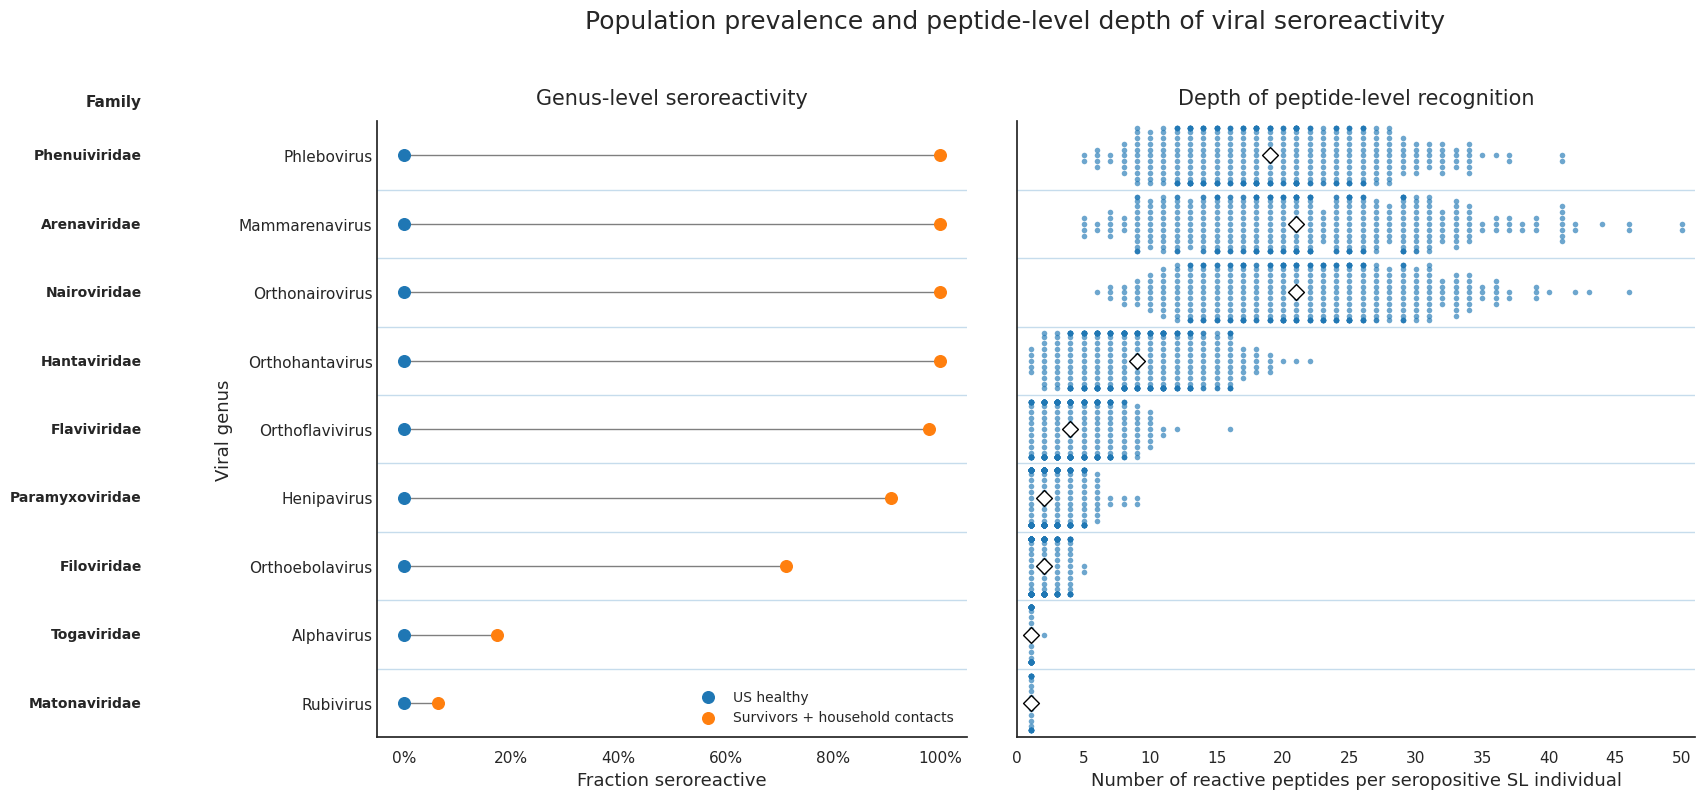

In [31]:
# 15. CREATE FIGURE
#
# sharey=True + exact same genus ordering guarantees that
# both panels occupy the same rows.


fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8),
    sharey=True,
    gridspec_kw={
        'width_ratios': [
            1,
            1.15
        ],
        'wspace': 0.08
    }
)


# PANEL A


ax = axes[0]

y = np.arange(
    len(representative_genus)
)


# US healthy

if 'HBDB' in representative_genus.columns:

    ax.scatter(
        representative_genus[
            'HBDB'
        ],
        y,
        s=70,
        label='US healthy',
        zorder=3
    )


# SL


ax.scatter(
    representative_genus[
        'SL'
    ],
    y,
    s=70,
    label='Survivors + household contacts',
    zorder=3
)


# Connecting lines


if 'HBDB' in representative_genus.columns:

    for i, (_, row) in enumerate(
        representative_genus.iterrows()
    ):

        ax.plot(
            [
                row['HBDB'],
                row['SL']
            ],
            [
                i,
                i
            ],
            color='black',
            linewidth=1,
            alpha=0.5,
            zorder=1
        )


# Genus labels


ax.set_yticks(y)

ax.set_yticklabels(
    representative_genus[
        'genus'
    ],
    fontsize=11
)


# X-axis formatting


ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{x:.0%}'
    )
)

ax.set_xlabel(
    'Fraction seroreactive',
    fontsize=13
)

ax.set_ylabel(
    'Viral genus',
    fontsize=13
)

ax.set_title(
    'Genus-level seroreactivity',
    fontsize=15,
    pad=12
)



# Legend: TOP RIGHT


ax.legend(
    frameon=False,
    loc='lower right',
    fontsize=10
)


# FAMILY LABELS
#
# Shown ONCE, to the left of Panel A.

for i, genus in enumerate(
    genus_order
):

    family = family_lookup[
        genus
    ]

    ax.text(
        -0.40,
        i,
        family,
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        clip_on=False
    )


# Family heading
ax.text(
    -0.40,
    1.02,
    'Family',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    clip_on=False
)


# PANEL B

ax = axes[1]


sns.swarmplot(
    data=genus_depth,
    x='n_reactive_peptides',
    y='genus',

    # EXACT SAME ORDER AS PANEL A
    order=genus_order,

    size=4,
    alpha=0.65,
    ax=ax
)


# MEDIAN DIAMONDS -


for i, genus in enumerate(
    genus_order
):

    median = depth_medians.loc[
        genus
    ]

    if pd.notna(median):

        ax.scatter(
            median,
            i,
            marker='D',
            s=65,
            facecolor='white',
            edgecolor='black',
            linewidth=1,
            zorder=10
        )



# PANEL B X-AXIS
#
# Show ticks every 5 peptides

max_depth = int(
    genus_depth[
        'n_reactive_peptides'
    ].max()
)

ax.set_xticks(
    np.arange(
        0,
        max_depth + 5,
        5
    )
)

ax.set_xlim(
    0,
    max_depth + 1
)



# LABELS -


ax.set_xlabel(
    'Number of reactive peptides per seropositive SL individual',
    fontsize=13
)

ax.set_ylabel('')

ax.set_title(
    'Depth of peptide-level recognition',
    fontsize=15,
    pad=12
)



# 16. MAKE Y-AXIS ALIGNMENT EXPLICIT

#
# Panel A and Panel B both have the same y positions because:
#
#   Panel A -> representative_genus sorted ascending SL
#   Panel B -> order=genus_order
#   sharey=True
#
# No invert_yaxis() is required.


axes[0].set_ylim(
    -0.5,
    len(genus_order) - 0.5
)

axes[1].set_ylim(
    -0.5,
    len(genus_order) - 0.5
)



# 17. OPTIONAL FAMILY SEPARATORS
#
# Family names remain only on the left, but separators help
# visually group related genera across both panels.


family_sequence = [
    family_lookup[
        genus
    ]
    for genus in genus_order
]


for i in range(
    len(family_sequence) - 1
):

    if (
        family_sequence[i]
        != family_sequence[i + 1]
    ):

        boundary = i + 0.5

        axes[0].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )

        axes[1].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )



# 18. CLEAN UP


for ax in axes:

    sns.despine(
        ax=ax
    )

    ax.tick_params(
        axis='y',
        length=0
    )


# 19. OVERALL TITLE


fig.suptitle(
    (
        'Population prevalence and peptide-level depth '
        'of viral seroreactivity'
    ),
    fontsize=18,
    y=1.02
)



# 20. SAVE


plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure1_genus_prevalence_and_depth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Figure 2 — Individual viral seroreactivity heatmap

**Question:** How are the population-level signals distributed across individuals?

The two species with the highest SL seroreactive prevalence within each viral family are shown. Species are grouped by family and ordered within each family by SL prevalence. Individuals are grouped as **Lassa survivors → household contacts → US healthy**, with hierarchical clustering performed separately within each outcome/reference group using the complete species-level maximum z-score profile.

For clustering, Euclidean distance and Ward linkage are used. The dendrograms are not displayed; clustering only determines the order of individuals.

In [51]:
# FIGURE 2:
# INDIVIDUAL VIRAL SEROREACTIVITY HEATMAP
#
# Figure 1:
#   representative genus = highest SL seroprevalence
#   within each viral family
#
# Figure 2:
#   top 3 species within each Figure 1 representative genus
#
# Heatmap value:
#   maximum peptide z-score for each individual x species
#
# Cohorts:
#   Lassa survivors
#   Household contacts
#   US healthy
#
# Individual ordering:
#   hierarchical clustering separately within each cohort
#
# Species ordering:
#   Figure 1 genus order
#   -> within genus, descending SL prevalence
#


# 0. SETTINGS -

TOP_N_SPECIES_PER_GENUS = 3

HEATMAP_VMAX = 8
HEATMAP_VMIN = 3

FIGURE_WIDTH = 35
FIGURE_HEIGHT = 20


# 1. COLLAPSE TO INDIVIDUAL x SPECIES
#
# max_z_score:
#   strongest peptide response for that species
#
# seroreactive:
#   >=1 peptide with z > 3
# 
species_individual = (
    long
    .groupby(
        [
            'species',
            'individual',
            'cohort',
            'genus',
            'family'
        ],
        observed=True
    )
    .agg(
        max_z_score=(
            'z_score',
            'max'
        ),
        seroreactive=(
            'reactive',
            'any'
        )
    )
    .reset_index()
)


# 2. SPECIES PREVALENCE IN THE SL COHORT -
#
# This is used to select the top 3 species within each
# representative genus.

sl_species_prev = (
    species_individual[
        species_individual['cohort'] == 'SL'
    ]
    .groupby(
        [
            'species',
            'genus',
            'family'
        ],
        observed=True
    )['seroreactive']
    .mean()
    .reset_index(
        name='SL_prevalence'
    )
)


In [52]:

# 3. REPRESENTATIVE GENERA FROM FIGURE 1 -


representative_genera = (
    representative_genus[
        'genus'
    ]
    .dropna()
    .unique()
    .tolist()
)


print(
    f'\nRepresentative genera from Figure 1: '
    f'{len(representative_genera)}'
)


# 4. KEEP SPECIES BELONGING TO THOSE GENERA -

species_candidates = (
    sl_species_prev[
        sl_species_prev['genus'].isin(
            representative_genera
        )
    ]
    .copy()
)


# 5. TOP 3 SPECIES PER REPRESENTATIVE GENUS

selected_species_df = (
    species_candidates
    .sort_values(
        [
            'genus',
            'SL_prevalence'
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        'genus',
        observed=True,
        group_keys=False
    )
    .head(
        TOP_N_SPECIES_PER_GENUS
    )
    .copy()
)


# 6. ORDER GENERA ACCORDING TO FIGURE 1
#
# Figure 1 order = descending SL seroprevalence.


genus_order = (
    representative_genus
    .sort_values(
        'SL',
        ascending=False
    )[
        'genus'
    ]
    .tolist()
)


# Keep only genera represented in Figure 2
genus_order = [
    genus
    for genus in genus_order
    if genus in
    selected_species_df[
        'genus'
    ].unique()
]


#7. ORDER SPECIES WITHIN EACH GENUS
#
# Highest SL prevalence first.


species_order = []

for genus in genus_order:

    genus_species = (
        selected_species_df[
            selected_species_df[
                'genus'
            ] == genus
        ]
        .sort_values(
            'SL_prevalence',
            ascending=False
        )[
            'species'
        ]
        .tolist()
    )

    species_order.extend(
        genus_species
    )


for species in species_order:

    row = (
        selected_species_df[
            selected_species_df[
                'species'
            ] == species
        ]
        .iloc[0]
    )

    print(
        f"{row['family']} | "
        f"{row['genus']} | "
        f"{species} | "
        f"SL={row['SL_prevalence']:.1%}"
    )


# 8. CREATE SPECIES x INDIVIDUAL MATRIX


heatmap_long = (
    species_individual[
        species_individual[
            'species'
        ].isin(
            species_order
        )
    ]
    .copy()
)


species_person_z = (
    heatmap_long
    .pivot(
        index='species',
        columns='individual',
        values='max_z_score'
    )
    .reindex(
        species_order
    )
)


# 9. INDIVIDUAL -> COHORT


individual_cohort = (
    heatmap_long[
        [
            'individual',
            'cohort'
        ]
    ]
    .drop_duplicates(
        'individual'
    )
    .set_index(
        'individual'
    )[
        'cohort'
    ]
)


# Keep only individuals actually present in the matrix
individual_cohort = (
    individual_cohort[
        individual_cohort.index.isin(
            species_person_z.columns
        )
    ]
)


species_person_z = (
    species_person_z[
        individual_cohort.index
    ]
)



# 9. DEFINE THE THREE GROUPS
#
# IMPORTANT:
# `cohort` only distinguishes SL vs HBDB.
#
# Within SL:
#   S-... = survivor
#   C-... = household contact


survivor_individuals = (
    individual_cohort[
        (
            individual_cohort == 'SL'
        )
        &
        (
            individual_cohort.index
            .astype(str)
            .str.startswith('S-')
        )
    ]
    .index
    .tolist()
)


contact_individuals = (
    individual_cohort[
        (
            individual_cohort == 'SL'
        )
        &
        (
            individual_cohort.index
            .astype(str)
            .str.startswith('C-')
        )
    ]
    .index
    .tolist()
)


hbdb_individuals = (
    individual_cohort[
        individual_cohort == 'HBDB'
    ]
    .index
    .tolist()
)


# 10. SANITY CHECK


n_sl_total = (
    (individual_cohort == 'SL')
    .sum()
)

n_classified_sl = (
    len(survivor_individuals)
    + len(contact_individuals)
)

print(
    '\nCOHORT COUNTS'
)

print(
    f'All SL individuals: '
    f'{n_sl_total}'
)

print(
    f'Lassa survivors: '
    f'{len(survivor_individuals)}'
)

print(
    f'Household contacts: '
    f'{len(contact_individuals)}'
)

print(
    f'US healthy: '
    f'{len(hbdb_individuals)}'
)

print(
    f'Unclassified SL individuals: '
    f'{n_sl_total - n_classified_sl}'
)


# Show unexpected SL IDs, if any
unclassified_sl = [
    x
    for x in individual_cohort[
        individual_cohort == 'SL'
    ].index
    if not (
        str(x).startswith('S-')
        or str(x).startswith('C-')
    )
]

if len(unclassified_sl) > 0:

    print(
        '\nWARNING: unexpected SL individual IDs:'
    )

    print(
        unclassified_sl[:20]
    )


# 11. CLUSTERING FUNCTION --
#
# Ward hierarchical clustering
# Euclidean distance
#
# Clustering is used ONLY to order individuals
# within each cohort.


from scipy.cluster.hierarchy import (
    linkage,
    leaves_list
)


def order_individuals_by_clustering(
    matrix
):

    # individuals x species
    X = (
        matrix
        .fillna(0)
        .T
    )

    if X.shape[0] <= 1:

        return (
            X.index.tolist(),
            None
        )

    linkage_matrix = linkage(
        X,
        method='ward',
        metric='euclidean'
    )

    ordered_idx = (
        leaves_list(
            linkage_matrix
        )
    )

    ordered_individuals = (
        X.index[
            ordered_idx
        ]
        .tolist()
    )

    return (
        ordered_individuals,
        linkage_matrix
    )


# 12. CLUSTER SURVIVORS -


survivor_ordered, survivor_linkage = (
    order_individuals_by_clustering(
        species_person_z[
            survivor_individuals
        ]
    )
)

# 13. CLUSTER HOUSEHOLD CONTACTS -


contact_ordered, contact_linkage = (
    order_individuals_by_clustering(
        species_person_z[
            contact_individuals
        ]
    )
)



# 14. CLUSTER US HEALTHY


hbdb_ordered, hbdb_linkage = (
    order_individuals_by_clustering(
        species_person_z[
            hbdb_individuals
        ]
    )
)



# 15. FINAL INDIVIDUAL ORDER -
#
# SURVIVORS -> CONTACTS -> US HEALTHY


ordered_individuals = (
    survivor_ordered
    + contact_ordered
    + hbdb_ordered
)


# 16. FINAL ORDER CHECK


assert (
    len(ordered_individuals)
    ==
    len(
        species_person_z.columns
    )
)


print(
    '\nFINAL ORDER'
)

print(
    f'Survivors: '
    f'{len(survivor_ordered)}'
)

print(
    f'Household contacts: '
    f'{len(contact_ordered)}'
)

print(
    f'US healthy: '
    f'{len(hbdb_ordered)}'
)




Representative genera from Figure 1: 9
Phenuiviridae | Phlebovirus | Phlebovirus cacaoense | SL=59.9%
Phenuiviridae | Phlebovirus | Phlebovirus ntepesense | SL=59.4%
Phenuiviridae | Phlebovirus | Phlebovirus limboense | SL=57.7%
Nairoviridae | Orthonairovirus | Orthonairovirus haemorrhagiae | SL=94.7%
Nairoviridae | Orthonairovirus | Orthonairovirus erveense | SL=72.5%
Nairoviridae | Orthonairovirus | Orthonairovirus nairobiense | SL=70.8%
Arenaviridae | Mammarenavirus | Mammarenavirus lassaense | SL=99.0%
Arenaviridae | Mammarenavirus | Mammarenavirus choriomeningitidis | SL=85.1%
Arenaviridae | Mammarenavirus | Mammarenavirus lunaense | SL=61.5%
Hantaviridae | Orthohantavirus | Orthohantavirus hantanense | SL=49.9%
Hantaviridae | Orthohantavirus | Orthohantavirus artybashense | SL=36.8%
Hantaviridae | Orthohantavirus | Huangpi virus | SL=36.3%
Flaviviridae | Orthoflavivirus | Orthoflavivirus denguei | SL=94.5%
Flaviviridae | Orthoflavivirus | Orthoflavivirus zikaense | SL=42.8%
Flav

/tmp/ipykernel_2744722/2051973263.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


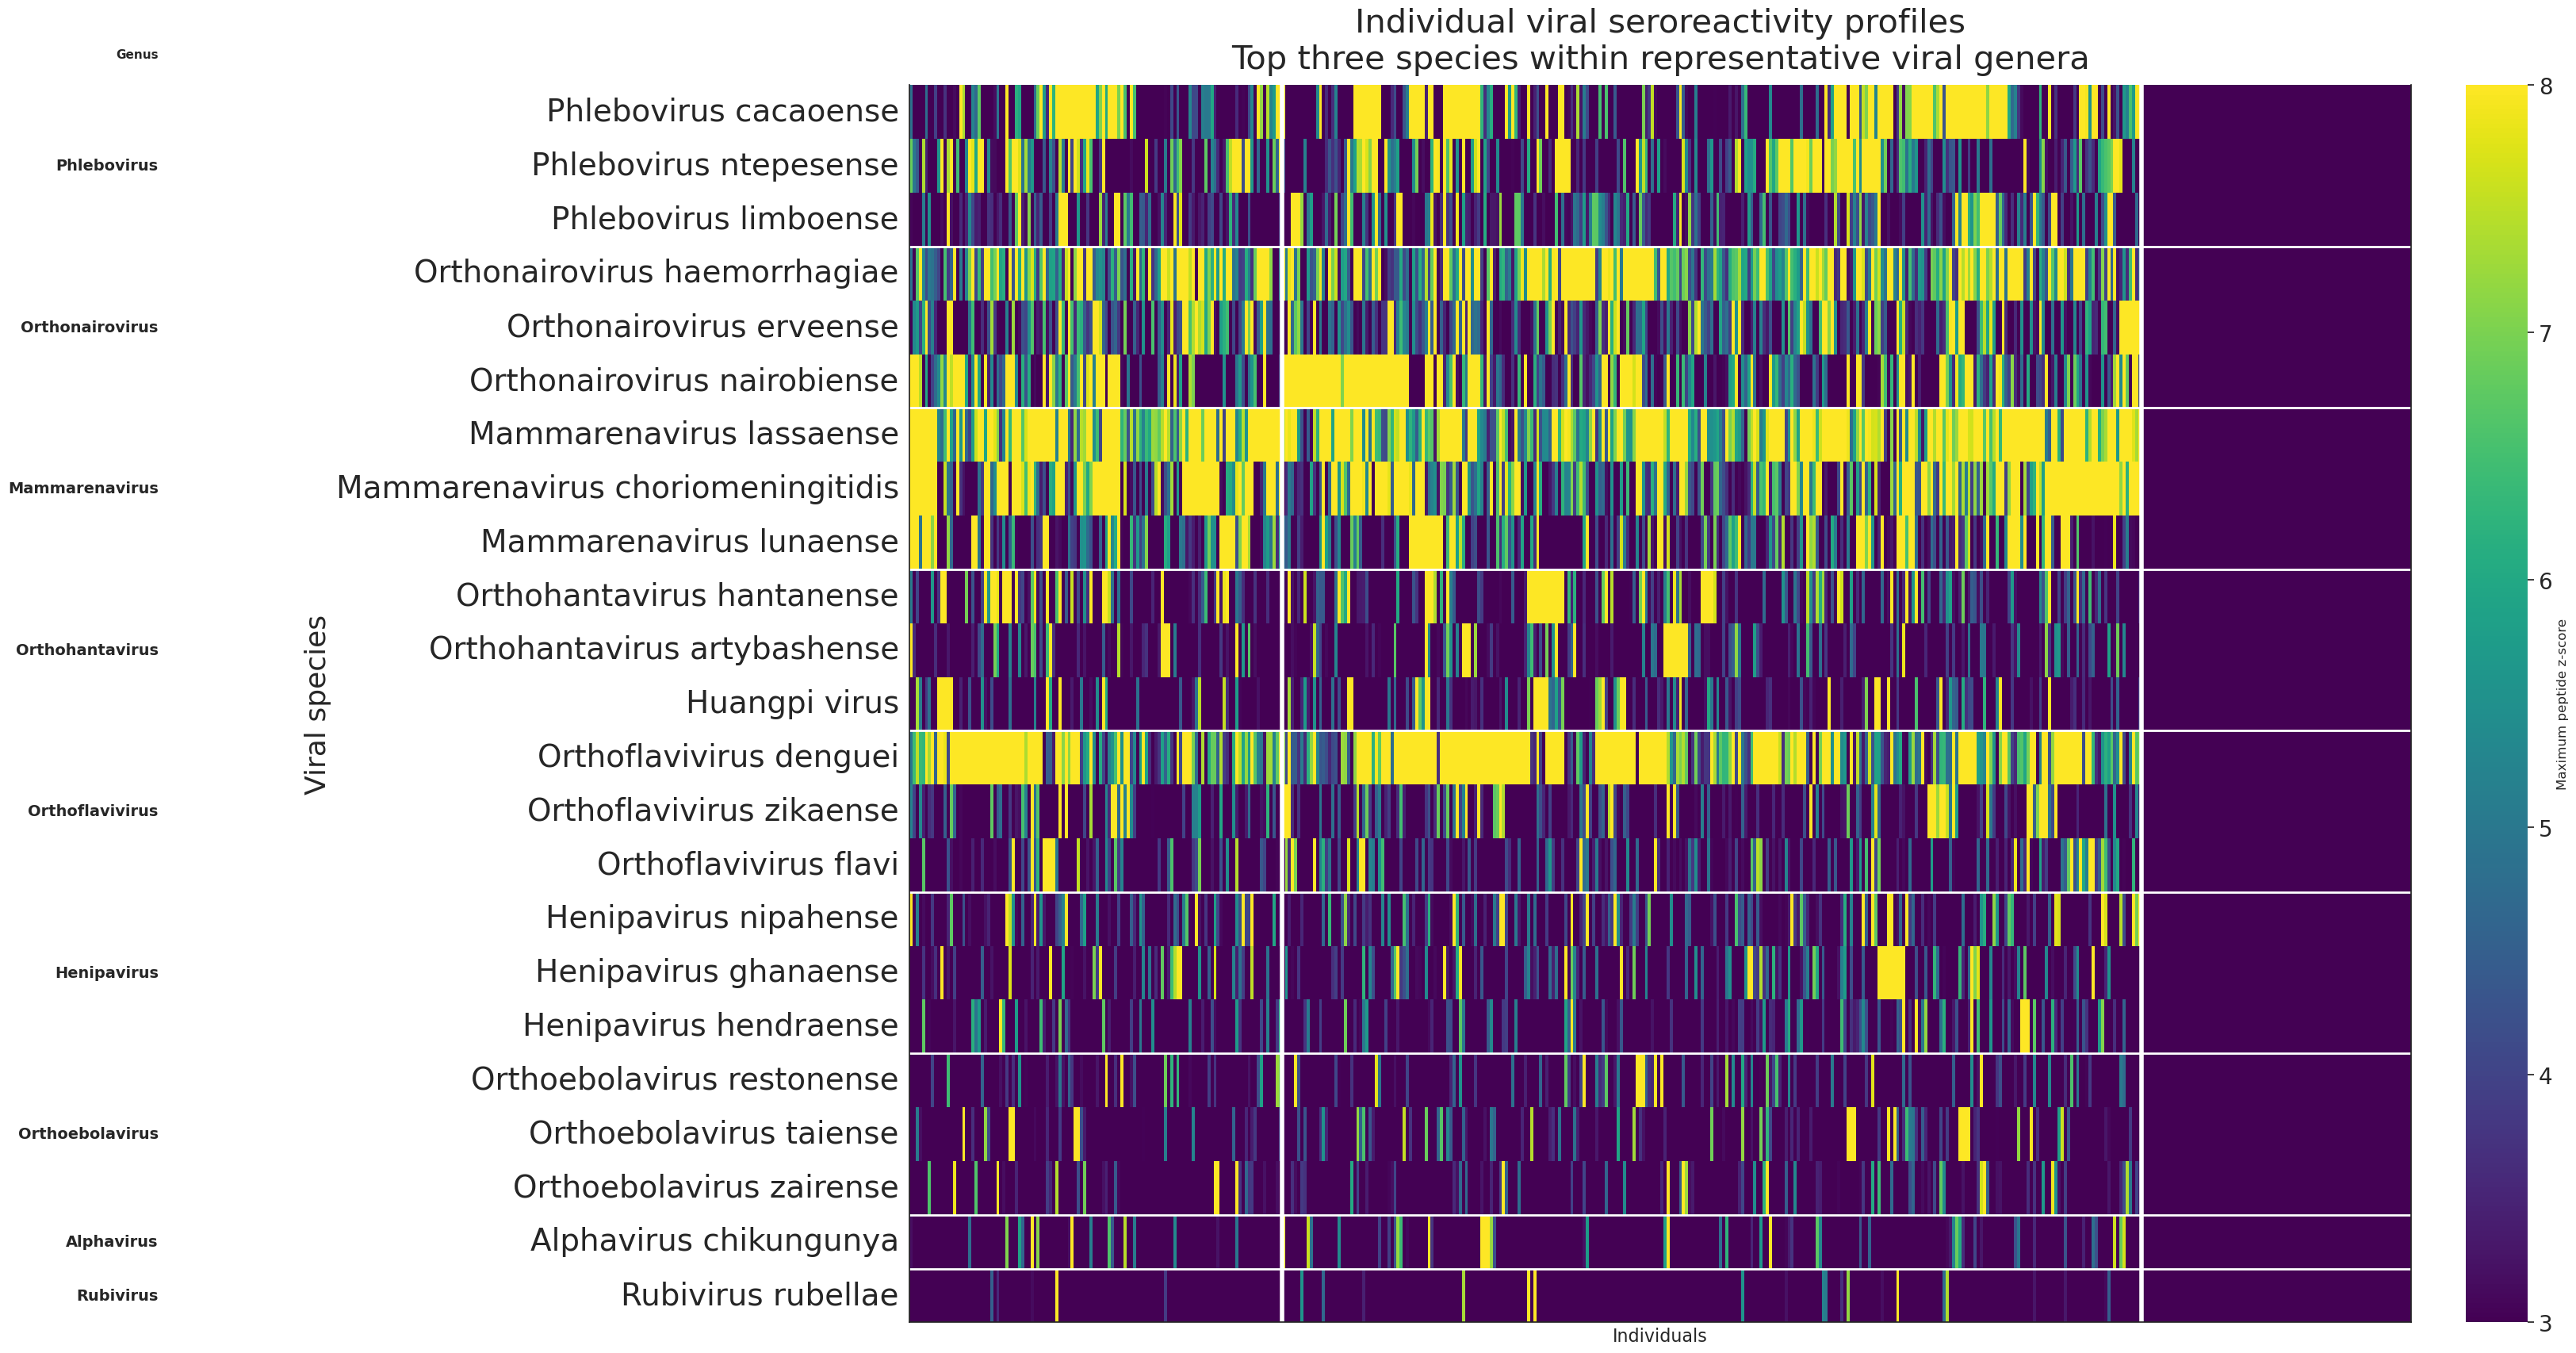

In [53]:


# 17. FINAL HEATMAP MATRIX --


plot_matrix = (
    species_person_z[
        ordered_individuals
    ]
    .clip(
        lower=HEATMAP_VMIN,
        upper=HEATMAP_VMAX
    )
)


#  18 . FIGURE --


fig = plt.figure(
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT
    )
)


# Main heatmap -


ax_heat = fig.add_axes([
    0.16,
    0.10,
    0.66,
    0.78
])



# 19. HEATMAP -


sns.heatmap(
    plot_matrix,
    ax=ax_heat,

    cmap='viridis',

    vmin=HEATMAP_VMIN,
    vmax=HEATMAP_VMAX,

    xticklabels=False,
    yticklabels=True,

    linewidths=0,

    cbar_kws={
        'label':
        'Maximum peptide z-score',
        'pad': 0.03
    }
)


# 20. SPECIES LABELS

ax_heat.set_yticklabels(
    plot_matrix.index,
    fontsize=18
)

ax_heat.set_ylabel(
    'Viral species',
    fontsize=16
)

ax_heat.set_xlabel(
    'Individuals',
    fontsize=16
)


# 21. COHORT BOUNDARIES


n_survivor = len(
    survivor_ordered
)

n_contact = len(
    contact_ordered
)

n_hbdb = len(
    hbdb_ordered
)


# Survivor / contact
if (
    n_survivor > 0
    and n_contact > 0
):

    ax_heat.axvline(
        n_survivor,
        color='white',
        linewidth=4
    )


# Contact / healthy
if (
    n_contact > 0
    and n_hbdb > 0
):

    ax_heat.axvline(
        n_survivor + n_contact,
        color='white',
        linewidth=4
    )



# 22. SPECIES METADATA

species_metadata = (
    selected_species_df
    .set_index('species')
    .loc[
        plot_matrix.index
    ]
)


genus_sequence = (
    species_metadata[
        'genus'
    ]
    .tolist()
)


# GENUS / SPECIES ANNOTATION
#
# Family annotation removed for a cleaner figure.
#
# Genus = separate grouped label
# Species = row labels immediately adjacent to heatmap

species_metadata = (
    selected_species_df
    .set_index('species')
    .loc[
        plot_matrix.index
    ]
)


genus_sequence = (
    species_metadata[
        'genus'
    ]
    .tolist()
)



# FIND GENUS BLOCKS


genus_blocks = []

current_genus = None
start = 0

for i, genus in enumerate(
    genus_sequence
):

    if genus != current_genus:

        if current_genus is not None:

            genus_blocks.append(
                (
                    current_genus,
                    start,
                    i - 1
                )
            )

        current_genus = genus
        start = i


genus_blocks.append(
    (
        current_genus,
        start,
        len(
            genus_sequence
        ) - 1
    )
)


# GENUS LABELS
#
# One label centered over each genus block

for genus, start, end in genus_blocks:

    center = (
        start + end + 1
    ) / 2

    ax_heat.text(
        -0.5,
        center,
        genus,
        transform=ax_heat.get_yaxis_transform(),
        ha='right',
        va='center',
        fontsize=14,
        fontweight='bold',
        clip_on=False
    )


# Genus heading
ax_heat.text(
    -0.5,
    1.02,
    'Genus',
    transform=ax_heat.transAxes,
    ha='right',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    clip_on=False
)



# GENUS SEPARATORS


for genus, start, end in (
    genus_blocks[:-1]
):

    ax_heat.axhline(
        end + 1,
        color='white',
        linewidth=2,
        alpha=1
    )


# SPECIES LABELS


ax_heat.set_yticklabels(
    plot_matrix.index,
    fontsize=28
)

ax_heat.set_ylabel(
    'Viral species',
    fontsize=26
)


# TITLE


ax_heat.set_title(
    (
        'Individual viral seroreactivity profiles\n'
        'Top three species within representative viral genera'
    ),
    fontsize=30,
    pad=15
)



# COLORBAR


cbar = (
    ax_heat
    .collections[0]
    .colorbar
)

cbar.ax.tick_params(
    labelsize=20
)


# CLEAN UP


sns.despine(
    ax=ax_heat,
    right=False
)

plt.tight_layout()


# 39. SAVE


fig.savefig(
    f'{FIG_DIR}/Figure2_individual_species_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

# Figure 3: LASV ELISA data X PhIP-Seq seropositivity data 
**question:** does the LASV ELISA data reflect the seropositivity observed in the SL cohort? 
 an individual is defined LASV seropositive by PhIP-Seq, if at least one retained peptide passed z > 3. 

In [72]:
lasv_elisa_data = pd.read_csv(LASV_ELISA_FILE).set_index('species')
lasv_elisa_data.drop(columns='Unnamed: 0', inplace=True)

In [80]:
lasv = long[
    long['species'] == 'Mammarenavirus lassaense'
].copy()

lasv_seroreactive = (
    lasv.groupby('individual', as_index=False) #as_index =False to remain a regular column in the resulting dataframe
    .agg(
        n_LASV_reactive_peptides=('reactive', 'sum'),
        LASV_seroreactive=('reactive', 'any')
    )
)

In [83]:
lasv_concordance = lasv_elisa_data.merge(
    lasv_seroreactive, 
    on='individual', 
    how='left'
)

#match Negative / Positive from ELISA data
lasv_concordance['PhIP-Seq result'] = (
    lasv_concordance['LASV_seroreactive']
    .map({True: 'Positive', False:'Negative'})
)

In [94]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(['count', 'median', 'mean', 'std', 'min', 'max'])

,count,median,mean,std,min,max
Serology_Result_Corrected,,,,,,
Negative,50,5.0,5.200000,3.458205,0,14
Positive,347,7.0,7.677233,4.517100,0,27


In [95]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(
    n='count',
    median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

,n,median,Q1,Q3
Serology_Result_Corrected,,,,
Negative,50,5.0,3.0,6.0
Positive,347,7.0,4.0,10.0


In [98]:
from scipy.stats import mannwhitneyu

neg = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Negative',
    'n_LASV_reactive_peptides'
]

pos = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Positive',
    'n_LASV_reactive_peptides'
]

mannwhitneyu(pos, neg, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(11624.0), pvalue=np.float64(9.698789032538046e-05))

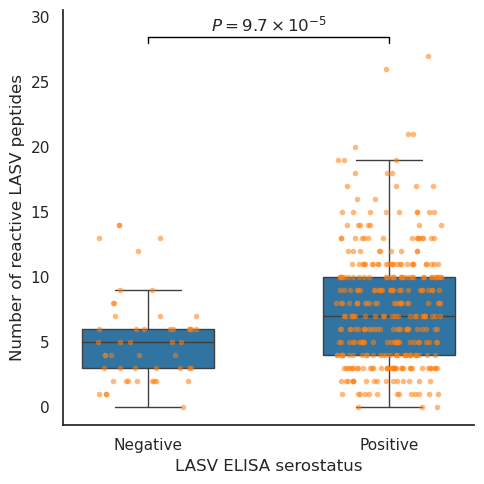

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

order = ['Negative', 'Positive']

sns.boxplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    jitter=0.22,
    alpha=0.55,
    size=4,
    ax=ax
)

ax.set_xlabel('LASV ELISA serostatus')
ax.set_ylabel('Number of reactive LASV peptides')

# Statistical annotation
ymax = lasv_concordance['n_LASV_reactive_peptides'].max()
y = ymax + 1

ax.plot([0, 0, 1, 1], [y, y+0.4, y+0.4, y], c='black', lw=1)
ax.text(
    0.5, y + 0.6,
    r'$P = 9.7 \times 10^{-5}$',
    ha='center',
    va='bottom'
)

ax.set_ylim(top=y + 2.5)

sns.despine()
plt.tight_layout()
plt.show()

### now address cross-reactivity issue

# Figure 4 — Sequence-linked peptide networks

**Question:** Could multi-species seroreactivity reflect shared sequence features among viral peptide targets?

The network is built from **all filtered peptides**, not only those displayed in the heatmap. Two peptides are connected when they share an exact 8-amino-acid k-mer; connected components define sequence-linked peptide clusters.

We then select two biologically targeted examples:
- the broadest cross-species *Mammarenavirus* cluster containing at least one *Mammarenavirus lassaense* peptide;
- the broadest cross-species *Orthonairovirus* cluster containing at least one *Orthonairovirus haemorrhagiae* peptide.

Node color = species; node shape = standardized protein class; node size = fraction of SL individuals with z>3 for that peptide. Peptide labels are deliberately omitted for readability.

In [ ]:
# ============================================================
# FIGURE 4: BUILD ALL-PEPTIDE 8-MER NETWORK
# ============================================================

K = 8


def get_kmers(sequence, k=K):
    sequence = str(sequence).upper()
    if len(sequence) < k:
        return set()
    return {
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    }

# Peptide prevalence in SL
sl_peptide_prevalence = (
    z_long[z_long['cohort'] == 'SL']
    .assign(reactive=lambda d: d['z_score'] > Z_THRESH)
    .groupby('peptide')['reactive']
    .mean()
    .rename('sl_prevalence')
    .reset_index()
)

network_hits = (
    hits[
        [
            'peptide', 'sequence', 'species', 'genus', 'family',
            'protein_name', 'protein_std'
        ]
    ]
    .drop_duplicates('peptide')
    .merge(
        sl_peptide_prevalence,
        on='peptide',
        how='left'
    )
)

network_hits['sl_prevalence'] = (
    network_hits['sl_prevalence'].fillna(0)
)

# Map k-mer -> peptides
kmer_to_peptides = defaultdict(list)

for peptide, sequence in (
    network_hits[['peptide', 'sequence']].itertuples(index=False)
):
    for kmer in get_kmers(sequence):
        kmer_to_peptides[kmer].append(peptide)

# Build graph
G_seq = nx.Graph()

for _, row in network_hits.iterrows():
    G_seq.add_node(
        row['peptide'],
        sequence=row['sequence'],
        species=row['species'],
        genus=row['genus'],
        family=row['family'],
        protein_name=row['protein_name'],
        protein_class=row['protein_class'],
        sl_prevalence=row['sl_prevalence']
    )

for kmer, peptides in kmer_to_peptides.items():
    peptides = list(set(peptides))
    if len(peptides) < 2:
        continue
    for p1, p2 in combinations(peptides, 2):
        if G_seq.has_edge(p1, p2):
            G_seq[p1][p2]['shared_kmers'].append(kmer)
        else:
            G_seq.add_edge(
                p1,
                p2,
                shared_kmers=[kmer]
            )

components_seq = list(
    nx.connected_components(G_seq)
)

print(f'Peptide nodes: {G_seq.number_of_nodes()}')
print(f'Edges: {G_seq.number_of_edges()}')
print(f'Connected components: {len(components_seq)}')

KeyError: "['protein_class'] not in index"

In [ ]:
# ============================================================
# SELECT TARGET-CONTAINING CLUSTERS
# ============================================================

def summarize_components(components, network_hits):
    records = []

    for cluster_id, component in enumerate(components):
        sub = network_hits[
            network_hits['peptide'].isin(component)
        ]

        species = sorted(
            sub['species'].dropna().unique().tolist()
        )
        genera = sorted(
            sub['genus'].dropna().unique().tolist()
        )
        families = sorted(
            sub['family'].dropna().unique().tolist()
        )
        proteins = sorted(
            sub['protein_class'].dropna().unique().tolist()
        )

        records.append({
            'cluster_id': cluster_id,
            'n_peptides': sub['peptide'].nunique(),
            'n_species': len(species),
            'n_genera': len(genera),
            'n_families': len(families),
            'species': species,
            'genera': genera,
            'families': families,
            'proteins': proteins
        })

    return pd.DataFrame(records)


cluster_summary = summarize_components(
    components_seq,
    network_hits
)


def select_target_cluster(
    target_species,
    target_genus
):
    candidates = cluster_summary[
        cluster_summary['species'].apply(
            lambda x: target_species in x
        )
        &
        cluster_summary['genera'].apply(
            lambda x: len(x) == 1 and x[0] == target_genus
        )
        &
        (cluster_summary['n_species'] >= 2)
    ].copy()

    if candidates.empty:
        return None, candidates

    candidates = (
        candidates
        .sort_values(
            ['n_species', 'n_peptides'],
            ascending=False
        )
        .reset_index(drop=True)
    )

    return candidates.iloc[0], candidates


mamma_selected, mamma_candidates = select_target_cluster(
    TARGET_LASSA,
    'Mammarenavirus'
)

ortho_selected, ortho_candidates = select_target_cluster(
    TARGET_HAEM,
    'Orthonairovirus'
)

if mamma_selected is None:
    raise ValueError(
        f'No cross-species Mammarenavirus cluster contains {TARGET_LASSA}.'
    )

if ortho_selected is None:
    raise ValueError(
        f'No cross-species Orthonairovirus cluster contains {TARGET_HAEM}.'
    )

print('Selected Mammarenavirus cluster:')
display(mamma_selected.to_frame().T)

print('Selected Orthonairovirus cluster:')
display(ortho_selected.to_frame().T)

print('Other qualifying Mammarenavirus clusters:')
display(mamma_candidates.head(10))

print('Other qualifying Orthonairovirus clusters:')
display(ortho_candidates.head(10))

Selected Mammarenavirus cluster:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,12,7,1,1,"[Mammarenavirus caliense, Mammarenavirus chori...",[Mammarenavirus],[Arenaviridae],[Glycoprotein]


Selected Orthonairovirus cluster:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,124,9,5,1,1,"[Orthonairovirus abuhammadense, Orthonairoviru...",[Orthonairovirus],[Nairoviridae],[Glycoprotein]


Other qualifying Mammarenavirus clusters:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,12,7,1,1,"[Mammarenavirus caliense, Mammarenavirus chori...",[Mammarenavirus],[Arenaviridae],[Glycoprotein]
1,162,6,6,1,1,"[Mammarenavirus batangense, Mammarenavirus bra...",[Mammarenavirus],[Arenaviridae],"[Glycoprotein, Polymerase]"
2,164,9,5,1,1,"[Mammarenavirus amapariense, Mammarenavirus ca...",[Mammarenavirus],[Arenaviridae],"[Glycoprotein, Polymerase]"
3,9,8,5,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],"[Glycoprotein, Polymerase]"
4,130,3,3,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],"[Glycoprotein, Polymerase]"
5,167,3,3,1,1,"[Mammarenavirus lassaense, Mammarenavirus luna...",[Mammarenavirus],[Arenaviridae],"[Glycoprotein, Nucleoprotein]"
6,166,3,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus sp.]",[Mammarenavirus],[Arenaviridae],[Matrix/Z]


Other qualifying Orthonairovirus clusters:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,124,9,5,1,1,"[Orthonairovirus abuhammadense, Orthonairoviru...",[Orthonairovirus],[Nairoviridae],[Glycoprotein]
1,399,2,2,1,1,"[Orthonairovirus haemorrhagiae, Orthonairoviru...",[Orthonairovirus],[Nairoviridae],"[Glycoprotein, Polymerase]"


In [ ]:
# ============================================================
# INSPECT THE PEPTIDE CONTENT OF THE TWO SELECTED CLUSTERS
# ============================================================


def inspect_cluster(cluster_row):
    component = components_seq[
        int(cluster_row['cluster_id'])
    ]

    return (
        network_hits[
            network_hits['peptide'].isin(component)
        ]
        [
            [
                'peptide',
                'sequence',
                'species',
                'genus',
                'family',
                'protein_name',
                'protein_class',
                'sl_prevalence'
            ]
        ]
        .sort_values(
            ['species', 'protein_class', 'peptide']
        )
        .reset_index(drop=True)
    )

mamma_data = inspect_cluster(mamma_selected)
ortho_data = inspect_cluster(ortho_selected)

print('Mammarenavirus selected cluster')
display(mamma_data)

print('Orthonairovirus selected cluster')
display(ortho_data)

Mammarenavirus selected cluster


,peptide,sequence,species,genus,family,protein_name,protein_class,sl_prevalence
0,AAB58486.1|precursor|Pichinde_virus|temperatur...,LKQLAKIPYCNYTKFWYINDTITGRHSLPQCWLVHNGSYLNETHFK,Mammarenavirus caliense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.052897
1,AFI42021.1|precursor|Mammarenavirus_choriomeni...,TVTPLISDQLLMRNHLRDLMGVPYCNSSKFWYLEHAKTGETSVPKC,Mammarenavirus choriomeningitidis,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.068010
2,WVH10120.1|precursor|Mammarenavirus_choriomeni...,TINSLISDQLLMRNHLRDLMGVPYCNYSKFWYLEHSKTNETSVPKC,Mammarenavirus choriomeningitidis,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.050378
3,YP_010839964.1|precursor|Kitale_virus|?|Grammo...,SKFWYLNDTRNGKTSLPKCWLISNGSYLNETHFSDQIEQEADNMIT,Mammarenavirus kitaleense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.073048
4,AZI96059.1|precursor|Mammarenavirus_lassaense|...,YWYLNNTVTGKSSLPKCWLVSNGSYLNETHFSEDIEQQADNMITEM,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.090680
5,AZI96476.1|precursor|Mammarenavirus_lassaense|...,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTITGKTSLPRCWLVSNGS,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.148615
6,AZI96488.1|precursor|Mammarenavirus_lassaense|...,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTVTGKTSLPRCWLVSNGT,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.168766
7,QWQ58036.1|precursor|Mammarenavirus_lunaense|A...,NDQLIIKNHLRDLMGIPYCNYSKFWYLNDTRNGKTSLPKCWKVSNN,Mammarenavirus lunaense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.070529
8,QWQ58036.1|precursor|Mammarenavirus_lunaense|A...,FWYLNDTRNGKTSLPKCWKVSNNSYLNETQFSNEITEEANNMITEM,Mammarenavirus lunaense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.118388
9,YP_006858706.1|precursor|Lunk_virus_NKS-1|?|Mu...,YSKFWYLEHYKTGETSLPKCWLVSNGSYLNETHFSDEIEQEANNMI,Mammarenavirus lunkense,Mammarenavirus,Arenaviridae,Glycoprotein/surface protein,Glycoprotein,0.070529


Orthonairovirus selected cluster


,peptide,sequence,species,genus,family,protein_name,protein_class,sl_prevalence
0,YP_010839818.1|precursor|Abu_Hammad_virus|isol...,SEILIFHKIPKDTDTLDLMKHYHITSAENACKLQSCTHGSAGDSQI,Orthonairovirus abuhammadense,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.120907
1,WPS63666.1|precursor|Erve_virus|isolate=KS12-1...,LPNEIITLHKVQGGEVDLMHVNKILTANSLCKLQSCTHGSPGDIQI,Orthonairovirus erveense,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.050378
2,WPS63668.1|precursor|Erve_virus|isolate=KS17-1...,LPSEIITLHKAQGGEVDLMHVNKILTANSLCKPQSCTHGSPGDIQI,Orthonairovirus erveense,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.070529
3,ARB51458.1|precursor|Orthonairovirus_haemorrha...,TVCKLQSCTHGVAGDLQVYHVGNLLKGDKINGHSIHKIEPHLNTSW,Orthonairovirus haemorrhagiae,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.057935
4,XKB88840.1|precursor|Orthonairovirus_haemorrha...,LPPEIITLHPKIEEGFFDLMHVQRVLSASTVCKLQSCTHGVPGDLQ,Orthonairovirus haemorrhagiae,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.095718
5,XMH26463.1|precursor|Orthonairovirus_haemorrha...,GNLLKGDKINGNSFHKIEPNLNTSWMSWDGCDLDYYCNMGDWPSCT,Orthonairovirus haemorrhagiae,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.057935
6,XQQ58330.1|precursor|Orthonairovirus_haemorrha...,CKLQSCTHGVPGDLQVYHIGNLLKGDKINGHMIHKIEPHFNTSWMS,Orthonairovirus haemorrhagiae,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.062972
7,WPV62121.1|glycoprotein|Wufeng_shrew_orthonair...,ASNLCKLQSCTHGAPGDIQIYKPNYLIKYSVSNKINSIEDGEIAND,Orthonairovirus sp.,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.060453
8,YP_009553333.1|precursor|Tunis_virus|isolate=?...,LPSEILIFHKIPKDADTLDLMKHYHITSAENACKLQSCTHGSVGDS,Orthonairovirus tunisense,Orthonairovirus,Nairoviridae,Glycoprotein/surface protein,Glycoprotein,0.075567


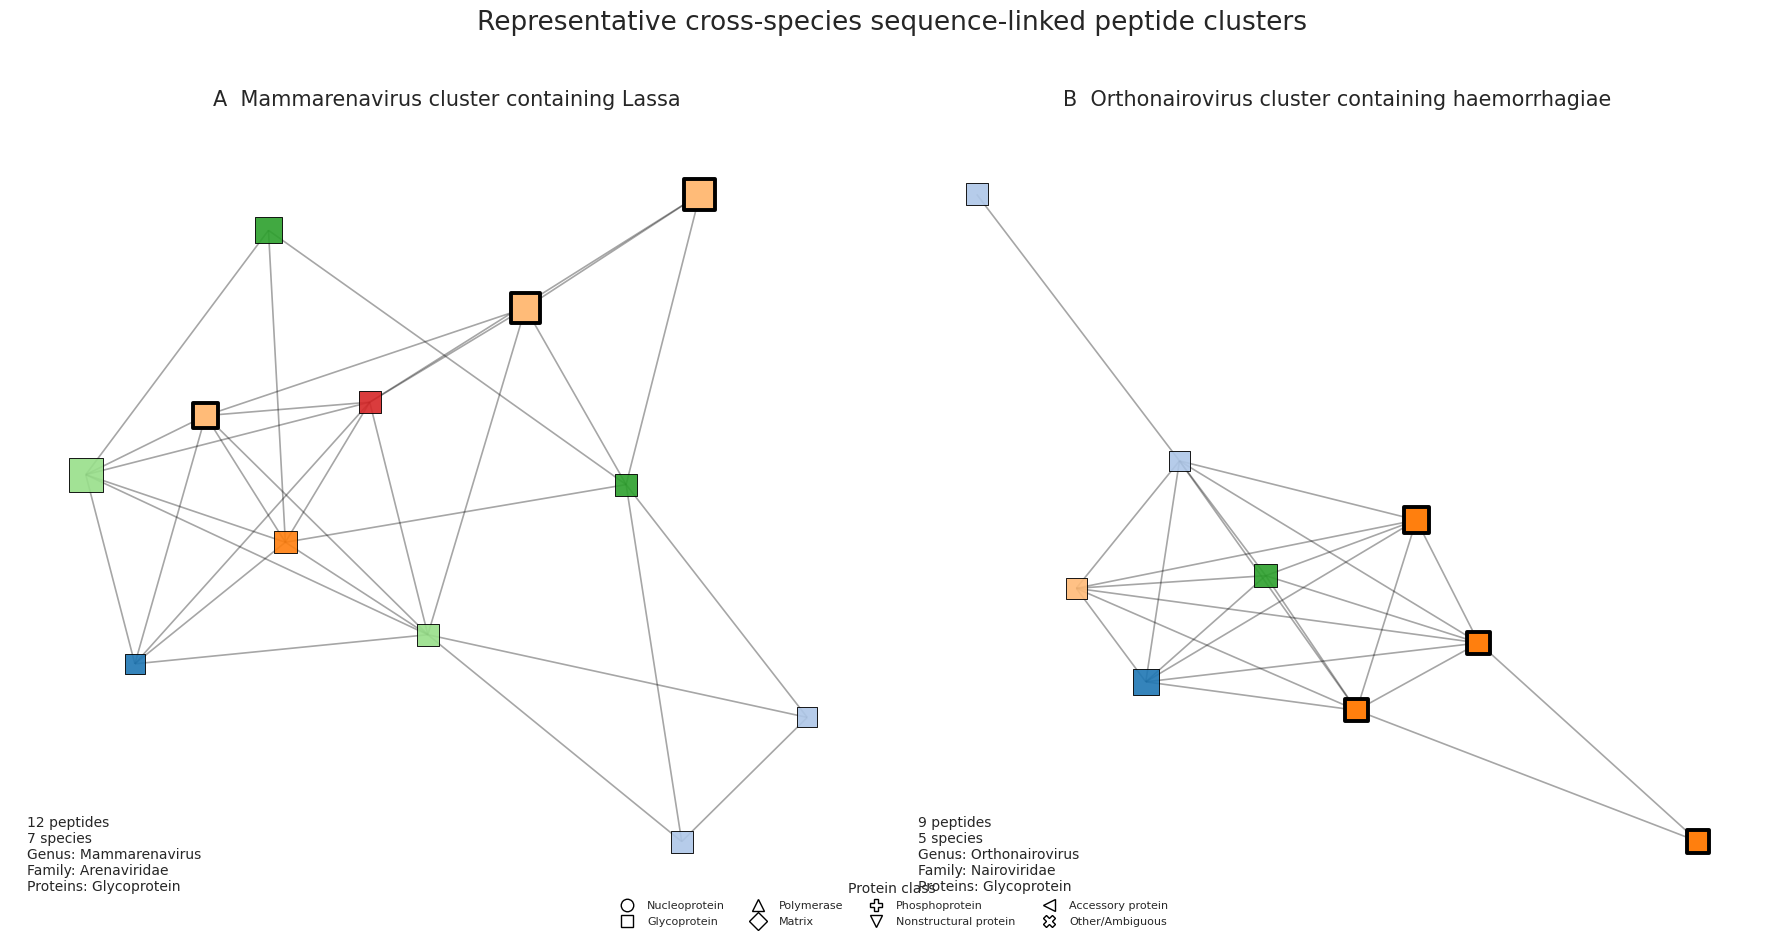

In [ ]:
# ============================================================
# FIGURE 4 PLOT
# ============================================================

protein_markers = {
    'Nucleoprotein': 'o',
    'Glycoprotein': 's',
    'Polymerase': '^',
    'Matrix': 'D',
    'Phosphoprotein': 'P',
    'Nonstructural protein': 'v',
    'Accessory protein': '<',
    'Other/Ambiguous': 'X'
}


def plot_cluster_network(ax, cluster_row, target_species, title):

    cluster_id = int(cluster_row['cluster_id'])
    component = components_seq[cluster_id]

    G = G_seq.subgraph(component).copy()

    pos = nx.spring_layout(
        G,
        seed=42,
        k=1.3,
        iterations=500
    )

    # Species palette local to the network
    species_here = sorted({
        G.nodes[node]['species']
        for node in G.nodes()
    })

    species_palette = {
        species: plt.cm.tab20(i % 20)
        for i, species in enumerate(species_here)
    }

    # Edges
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=1.2,
        alpha=0.35
    )

    # Nodes: color = species, shape = standardized protein class
    for protein_type, marker in protein_markers.items():

        nodes = [
            node
            for node in G.nodes()
            if G.nodes[node]['protein_class'] == protein_type
        ]

        if not nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=nodes,
            node_size=[
                100 + 2200 * G.nodes[node]['sl_prevalence']
                for node in nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.9
        )

    # Re-outline target species nodes WITHOUT changing their protein shapes
    for protein_type, marker in protein_markers.items():

        target_nodes = [
            node
            for node in G.nodes()
            if (
                G.nodes[node]['species'] == target_species
                and G.nodes[node]['protein_class'] == protein_type
            )
        ]

        if not target_nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=target_nodes,
            node_size=[
                130 + 2200 * G.nodes[node]['sl_prevalence']
                for node in target_nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in target_nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=2.8,
            alpha=1
        )

    # Metadata
    genera_here = sorted({
        G.nodes[node]['genus']
        for node in G.nodes()
    })

    families_here = sorted({
        G.nodes[node]['family']
        for node in G.nodes()
    })

    proteins_here = sorted({
        G.nodes[node]['protein_class']
        for node in G.nodes()
    })

    ax.text(
        0.02,
        0.02,
        (
            f'{G.number_of_nodes()} peptides\n'
            f'{len(species_here)} species\n'
            f'Genus: {", ".join(genera_here)}\n'
            f'Family: {", ".join(families_here)}\n'
            f'Proteins: {", ".join(proteins_here)}'
        ),
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            alpha=0.9,
            edgecolor='none'
        )
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=15
    )

    ax.axis('off')

    return species_palette


fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9)
)

mamma_palette = plot_cluster_network(
    axes[0],
    mamma_selected,
    TARGET_LASSA,
    'A  Mammarenavirus cluster containing Lassa'
)

ortho_palette = plot_cluster_network(
    axes[1],
    ortho_selected,
    TARGET_HAEM,
    'B  Orthonairovirus cluster containing haemorrhagiae'
)

# Protein legend
protein_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=9,
        label=protein_type
    )
    for protein_type, marker in protein_markers.items()
]

fig.legend(
    handles=protein_handles,
    title='Protein class',
    frameon=False,
    fontsize=8,
    title_fontsize=10,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    'Representative cross-species sequence-linked peptide clusters',
    fontsize=19,
    y=1.02
)

plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure4_representative_sequence_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Notes for interpretation

### Figure 1
Population-level seroreactivity identifies the viral species that contribute the strongest SL signals across multiple viral families.

### Figure 2
The heatmap moves to the individual level. It shows whether those population-level signals are shared broadly or arise from heterogeneous combinations of viral responses. The clustering is used only to order individuals; it does not establish discrete biological subgroups.

### Figure 3
This directly addresses the clinical/outcome question by testing survivor versus household-contact differences for the selected species. Because the displayed species were selected using the same cohort, this should be described as an exploratory outcome analysis unless an independent/pre-specified species set is used.

### Figure 4
The 8-mer networks address a mechanistic question raised by Figure 2: whether peptide targets assigned to different viral species can be sequence-linked. An edge means an exact shared 8-aa k-mer; a connected component can therefore include indirect chains of peptide relationships. Sequence linkage is evidence of shared sequence features, not experimental proof of antibody cross-reactivity.

### Protein annotation
Protein identity is taken from the standardized master peptide library. The original protein annotation is preserved there alongside standardized names/classes; this notebook does not infer protein identity from the peptide sequence itself.